In [1]:
!pip install phonemizer
!pip install optimum
!sudo apt-get install espeak-ng -y

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 4.3 MB/s eta 0:00:00
  Obtaining dependency information for clldutils>=1.7.3 from https://files.pythonhosted.org/packages/98/3e/9e617b2913c1afd6e62270599761031319e09c1b4a0999f03cb26572295a/clldutils-3.22.1-py2.py3-none-any.whl.metadata
  Obtaining dependency information for csvw>=1.5.6 from https://files.pythonhosted.org/packages/75/6b/1dab24bd962e8a6b90fbdb9498bc29fc3144ce43c61db0d71c94de38fe02/csvw-3.2.1-py2.py3-none-any.whl.metadata
  Obtaining dependency information for bibtexparser>=2.0.0b4 from https://files.pythonhosted.org/packages/d2/5b/d6324251d57be7833191173609dd30b495da8526f134b8a85ef32f124d4c/bibtexparser-2.0.0b5-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 21.0 MB/s eta 0:00:0

In [2]:
from dataclasses import dataclass
import torch
import IPython
import matplotlib.pyplot as plt

torch.random.manual_seed(0);

In [3]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from datasets import load_dataset


In [120]:
# load model and processor
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-lv-60-espeak-cv-ft", phone_delimiter_token=' ', word_delimiter_token=' ')
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-lv-60-espeak-cv-ft")

In [5]:
from optimum.bettertransformer import BetterTransformer

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [6]:
model = BetterTransformer.transform(model)

The BetterTransformer implementation does not support padding during training, as the fused kernels do not support attention masks. Beware that passing padded batched data during training may result in unexpected outputs. Please refer to https://huggingface.co/docs/optimum/bettertransformer/overview for more details.


In [7]:
# load dummy dataset and read soundfiles
ds = load_dataset("patrickvonplaten/librispeech_asr_dummy", "clean", split="validation")

Extracting data files:   0%|          | 0/1 [00:00<?, ?it/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Dataset librispeech_asr downloaded and prepared to /root/.cache/huggingface/datasets/patrickvonplaten___librispeech_asr/clean/2.1.0/f2c70a4d03ab4410954901bde48c54b85ca1b7f9bf7d616e7e2a72b5ee6ddbfc. Subsequent calls will reuse this data.


In [8]:
transcript = ds[0].copy()['text']

In [9]:
ds[0].copy()["audio"]["array"].shape

(174160,)

In [10]:
174160 / 16000

10.885

In [11]:
input_values = processor(ds[0].copy()["audio"]["array"], return_tensors="pt").input_values

It is strongly recommended to pass the ``sampling_rate`` argument to this function. Failing to do so can result in silent errors that might be hard to debug.


In [12]:
input_values.shape

torch.Size([1, 174160])

In [13]:
# retrieve logits
with torch.inference_mode():
    emissions = model(input_values,).logits
    emissions = torch.log_softmax(emissions, dim=-1)

emission = emissions[0].cpu().detach()

In [14]:
emission.size()

torch.Size([544, 392])

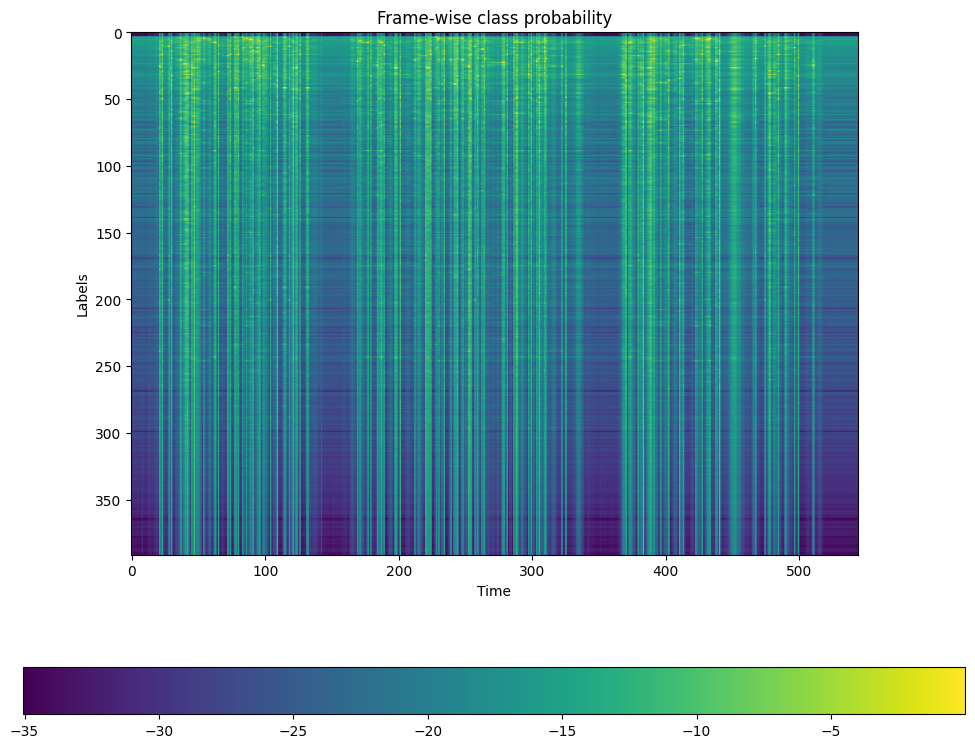

In [15]:
def plot(emission):
    fig, ax = plt.subplots(figsize=(16, 8))
    img = ax.imshow(emission.T)
    ax.set_title("Frame-wise class probability")
    ax.set_xlabel("Time")
    ax.set_ylabel("Labels")
    fig.colorbar(img, ax=ax, shrink=0.6, location="bottom")
    fig.tight_layout()


plot(emission.numpy())

In [16]:
def get_trellis(emission, tokens, blank_id=0):
    num_frame = emission.size(0)
    num_tokens = len(tokens)

    trellis = torch.zeros((num_frame, num_tokens))
    trellis[1:, 0] = torch.cumsum(emission[1:, blank_id], 0)
    trellis[0, 1:] = -float("inf")
    trellis[-num_tokens + 1 :, 0] = float("inf")

    for t in range(num_frame - 1):
        trellis[t + 1, 1:] = torch.maximum(
            # Score for staying at the same token
            trellis[t, 1:] + emission[t, blank_id],
            # Score for changing to the next token
            trellis[t, :-1] + emission[t, tokens[1:]],
        )
    return trellis

In [113]:
ph = processor.tokenizer.phonemize(transcript)
tokens = processor.tokenizer(transcript).input_ids

In [121]:
text = 'dioxide  from | the'
ph = processor.tokenizer.phonemize(text, )

In [122]:
ph

'd aɪ ɑː k s aɪ d   f ɹ ʌ m   ð ə'

In [81]:
words = text.split()
words_phonemes = ph.split('   ')
words_phoneme_mapping = [(w, p) for w, p in zip(words, words_phonemes)]

In [82]:
len(words)

17

In [83]:
len(words_phonemes)

16

In [248]:
words_phoneme_mapping

[('BECAUSE', 'b ɪ k ʌ z'),
 ('YOU', 'j uː'),
 ('WERE', 'w ɜː'),
 ('SLEEPING', 's l iː p ɪ ŋ'),
 ('INSTEAD', 'ɪ n s t ɛ d'),
 ('OF', 'ʌ v'),
 ('CONQUERING', 'k ɑː ŋ k ɚ ɹ ɪ ŋ'),
 ('THE', 'ð ə'),
 ('LOVELY', 'l ʌ v l i'),
 ('ROSE', 'ɹ oʊ z'),
 ('PRINCESS', 'p ɹ ɪ n s ɛ s'),
 ('HAS', 'h æ z'),
 ('BECOME', 'b ɪ k ʌ m'),
 ('A', 'ɐ'),
 ('FIDDLE', 'f ɪ d əl'),
 ('WITHOUT', 'w ɪ ð aʊ t'),
 ('A', 'ɐ'),
 ('BOW', 'b oʊ'),
 ('WHILE', 'w aɪ l'),
 ('POOR', 'p ʊɹ'),
 ('SHAGGY', 'ʃ æ ɡ i'),
 ('SITS', 's ɪ t s'),
 ('THERE', 'ð ɛ ɹ'),
 ('A', 'ɐ'),
 ('COOING', 'k uː ɪ ŋ'),
 ('DOVE', 'd ʌ v')]

In [247]:
ph = ph.replace('   ', ' ').split()

In [249]:
print(ph)

['b', 'ɪ', 'k', 'ʌ', 'z', 'j', 'uː', 'w', 'ɜː', 's', 'l', 'iː', 'p', 'ɪ', 'ŋ', 'ɪ', 'n', 's', 't', 'ɛ', 'd', 'ʌ', 'v', 'k', 'ɑː', 'ŋ', 'k', 'ɚ', 'ɹ', 'ɪ', 'ŋ', 'ð', 'ə', 'l', 'ʌ', 'v', 'l', 'i', 'ɹ', 'oʊ', 'z', 'p', 'ɹ', 'ɪ', 'n', 's', 'ɛ', 's', 'h', 'æ', 'z', 'b', 'ɪ', 'k', 'ʌ', 'm', 'ɐ', 'f', 'ɪ', 'd', 'əl', 'w', 'ɪ', 'ð', 'aʊ', 't', 'ɐ', 'b', 'oʊ', 'w', 'aɪ', 'l', 'p', 'ʊɹ', 'ʃ', 'æ', 'ɡ', 'i', 's', 'ɪ', 't', 's', 'ð', 'ɛ', 'ɹ', 'ɐ', 'k', 'uː', 'ɪ', 'ŋ', 'd', 'ʌ', 'v']


In [225]:
len(ph)

93

In [226]:
len(tokens)

93

In [227]:
print(tokens)

[26, 17, 11, 33, 21, 24, 46, 32, 63, 5, 8, 30, 18, 17, 42, 17, 4, 5, 6, 14, 12, 33, 25, 11, 41, 42, 11, 43, 27, 17, 42, 22, 7, 8, 33, 25, 8, 10, 27, 49, 21, 18, 27, 17, 4, 5, 14, 5, 39, 20, 21, 26, 17, 11, 33, 13, 20, 23, 17, 12, 61, 32, 17, 22, 53, 6, 20, 26, 49, 32, 37, 8, 18, 104, 38, 36, 35, 10, 5, 17, 6, 5, 22, 14, 27, 20, 11, 46, 17, 42, 12, 33, 25]


In [228]:
print(ph)

['b', 'ɪ', 'k', 'ʌ', 'z', 'j', 'uː', 'w', 'ɜː', 's', 'l', 'iː', 'p', 'ɪ', 'ŋ', 'ɪ', 'n', 's', 't', 'ɛ', 'd', 'ʌ', 'v', 'k', 'ɑː', 'ŋ', 'k', 'ɚ', 'ɹ', 'ɪ', 'ŋ', 'ð', 'ə', 'l', 'ʌ', 'v', 'l', 'i', 'ɹ', 'oʊ', 'z', 'p', 'ɹ', 'ɪ', 'n', 's', 'ɛ', 's', 'h', 'æ', 'z', 'b', 'ɪ', 'k', 'ʌ', 'm', 'ɐ', 'f', 'ɪ', 'd', 'əl', 'w', 'ɪ', 'ð', 'aʊ', 't', 'ɐ', 'b', 'oʊ', 'w', 'aɪ', 'l', 'p', 'ʊɹ', 'ʃ', 'æ', 'ɡ', 'i', 's', 'ɪ', 't', 's', 'ð', 'ɛ', 'ɹ', 'ɐ', 'k', 'uː', 'ɪ', 'ŋ', 'd', 'ʌ', 'v']


In [229]:
len(tokens)

93

In [230]:
print(ph)

['b', 'ɪ', 'k', 'ʌ', 'z', 'j', 'uː', 'w', 'ɜː', 's', 'l', 'iː', 'p', 'ɪ', 'ŋ', 'ɪ', 'n', 's', 't', 'ɛ', 'd', 'ʌ', 'v', 'k', 'ɑː', 'ŋ', 'k', 'ɚ', 'ɹ', 'ɪ', 'ŋ', 'ð', 'ə', 'l', 'ʌ', 'v', 'l', 'i', 'ɹ', 'oʊ', 'z', 'p', 'ɹ', 'ɪ', 'n', 's', 'ɛ', 's', 'h', 'æ', 'z', 'b', 'ɪ', 'k', 'ʌ', 'm', 'ɐ', 'f', 'ɪ', 'd', 'əl', 'w', 'ɪ', 'ð', 'aʊ', 't', 'ɐ', 'b', 'oʊ', 'w', 'aɪ', 'l', 'p', 'ʊɹ', 'ʃ', 'æ', 'ɡ', 'i', 's', 'ɪ', 't', 's', 'ð', 'ɛ', 'ɹ', 'ɐ', 'k', 'uː', 'ɪ', 'ŋ', 'd', 'ʌ', 'v']


In [231]:
emission.size()

torch.Size([544, 392])

In [250]:
trellis = get_trellis(emission, tokens)

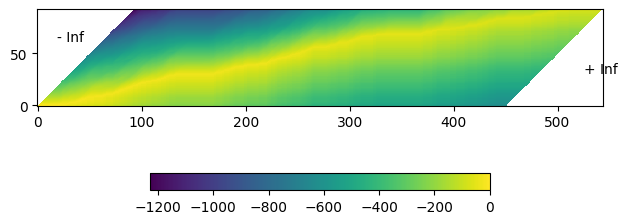

In [251]:
def plot():
    fig, ax = plt.subplots()
    img = ax.imshow(trellis.T, origin="lower")
    ax.annotate("- Inf", (trellis.size(1) / 5, trellis.size(1) / 1.5))
    ax.annotate("+ Inf", (trellis.size(0) - trellis.size(1) / 5, trellis.size(1) / 3))
    fig.colorbar(img, ax=ax, shrink=0.6, location="bottom")
    fig.tight_layout()


plot()

In [282]:
@dataclass
class Point:
    token_index: int
    time_index: int
    score: float


def backtrack(trellis, emission, tokens, blank_id=0):
    t, j = trellis.size(0) - 1, trellis.size(1) - 1

    path = [Point(j, t, emission[t, blank_id].exp().item())]
    while j > 0:
        # Should not happen but just in case
        assert t > 0

        # 1. Figure out if the current position was stay or change
        # Frame-wise score of stay vs change
        p_stay = emission[t - 1, blank_id]
        p_change = emission[t - 1, tokens[j]]

        # Context-aware score for stay vs change
        stayed = trellis[t - 1, j] + p_stay
        changed = trellis[t - 1, j - 1] + p_change

        # Update position
        t -= 1
        if changed > stayed:
            j -= 1

        # Store the path with frame-wise probability.
        prob = (p_change if changed > stayed else p_stay).exp().item()
        path.append(Point(j, t, prob))

    # Now j == 0, which means, it reached the SoS.
    # Fill up the rest for the sake of visualization
    while t > 0:
        prob = emission[t - 1, blank_id].exp().item()
        path.append(Point(j, t - 1, prob))
        t -= 1

    return path[::-1]


path = backtrack(trellis, emission, tokens)
for p in path:
    print(p)

Point(token_index=0, time_index=0, score=0.999996542930603)
Point(token_index=0, time_index=1, score=0.9999960660934448)
Point(token_index=0, time_index=2, score=0.999996542930603)
Point(token_index=0, time_index=3, score=0.9999955892562866)
Point(token_index=0, time_index=4, score=0.9999960660934448)
Point(token_index=0, time_index=5, score=0.9999963045120239)
Point(token_index=0, time_index=6, score=0.9999964237213135)
Point(token_index=0, time_index=7, score=0.9999967813491821)
Point(token_index=0, time_index=8, score=0.9999954700469971)
Point(token_index=0, time_index=9, score=0.9999974966049194)
Point(token_index=0, time_index=10, score=0.9999972581863403)
Point(token_index=0, time_index=11, score=0.9999974966049194)
Point(token_index=0, time_index=12, score=0.9999973773956299)
Point(token_index=0, time_index=13, score=0.9999942779541016)
Point(token_index=0, time_index=14, score=0.9999960660934448)
Point(token_index=0, time_index=15, score=0.999995231628418)
Point(token_index=0, 

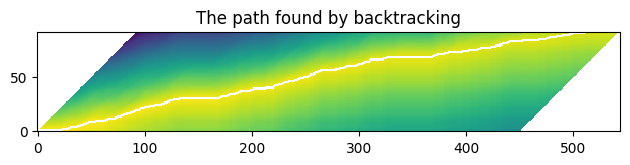

In [283]:
def plot_trellis_with_path(trellis, path):
    # To plot trellis with path, we take advantage of 'nan' value
    trellis_with_path = trellis.clone()
    for _, p in enumerate(path):
        trellis_with_path[p.time_index, p.token_index] = float("nan")
    plt.imshow(trellis_with_path.T, origin="lower")
    plt.title("The path found by backtracking")
    plt.tight_layout()


plot_trellis_with_path(trellis, path)

In [284]:
# Merge the labels
@dataclass
class Segment:
    label: str
    start: int
    end: int
    score: float

    def __repr__(self):
        return f"{self.label}\t({self.score:4.2f}): [{self.start:5d}, {self.end:5d}]"

    
    def __len__(self):
        return (self.end - self.start)


def merge_repeats(path):
    i1, i2 = 0, 0
    segments = []
    while i1 < len(path):
        while i2 < len(path) and path[i1].token_index == path[i2].token_index:
            i2 += 1
        score = sum(path[k].score for k in range(i1, i2)) / (i2 - i1)
        segments.append(
            Segment(
                ph[path[i1].token_index],
                path[i1].time_index,
                path[i2 - 1].time_index + 1,
                score,
            )
        )
        i1 = i2
    return segments


segments = merge_repeats(path)
for seg in segments:
    print(seg)

b	(0.95): [    0,    24]
ɪ	(1.00): [   24,    29]
k	(0.95): [   29,    31]
ʌ	(0.99): [   31,    38]
z	(0.91): [   38,    41]
j	(0.64): [   41,    43]
uː	(0.72): [   43,    46]
w	(0.63): [   46,    48]
ɜː	(0.99): [   48,    55]
s	(0.90): [   55,    64]
l	(0.97): [   64,    66]
iː	(1.00): [   66,    73]
p	(0.98): [   73,    75]
ɪ	(0.92): [   75,    79]
ŋ	(0.97): [   79,    81]
ɪ	(1.00): [   81,    84]
n	(0.99): [   84,    87]
s	(0.94): [   87,    90]
t	(0.56): [   90,    92]
ɛ	(0.94): [   92,    96]
d	(0.80): [   96,    97]
ʌ	(0.98): [   97,   100]
v	(1.00): [  100,   105]
k	(0.90): [  105,   110]
ɑː	(0.88): [  110,   116]
ŋ	(1.00): [  116,   119]
k	(0.92): [  119,   122]
ɚ	(0.99): [  122,   124]
ɹ	(0.90): [  124,   127]
ɪ	(0.95): [  127,   133]
ŋ	(1.00): [  133,   170]
ð	(0.98): [  170,   172]
ə	(1.00): [  172,   178]
l	(0.97): [  178,   180]
ʌ	(1.00): [  180,   185]
v	(0.99): [  185,   188]
l	(0.98): [  188,   190]
i	(0.92): [  190,   199]
ɹ	(0.95): [  199,   202]
oʊ	(1.00): [  202,   

In [268]:
len(segments[0])

24

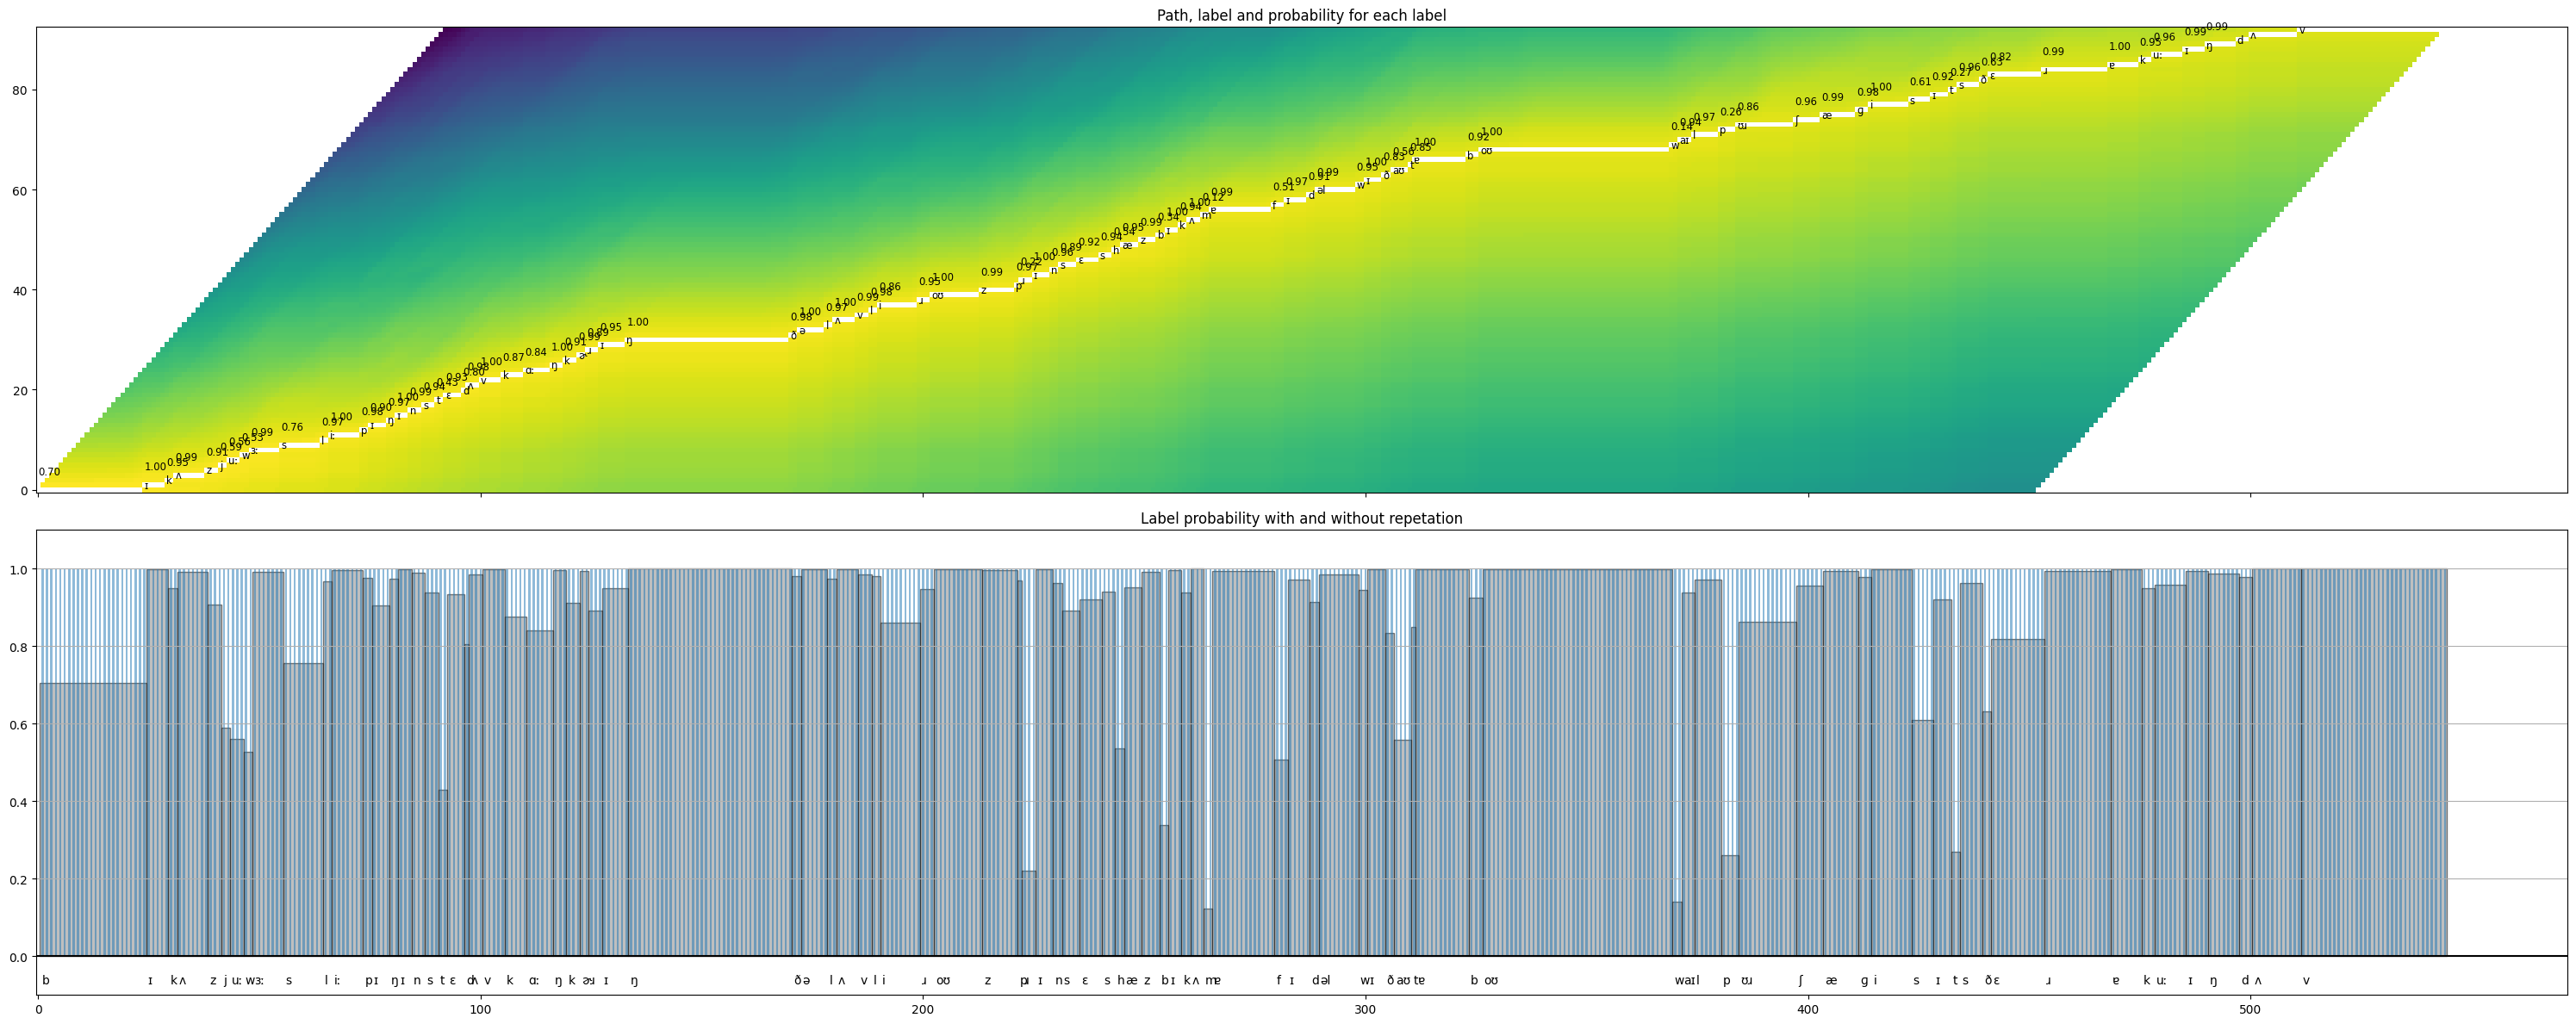

In [270]:
def plot_trellis_with_segments(trellis, segments, transcript):
    # To plot trellis with path, we take advantage of 'nan' value
    trellis_with_path = trellis.clone()
    for i, seg in enumerate(segments):
        if seg.label != "|":
            trellis_with_path[seg.start : seg.end, i] = float("nan")

    fig, [ax1, ax2] = plt.subplots(2, 1, sharex=True, figsize=(30, 12))
    ax1.set_title("Path, label and probability for each label")
    ax1.imshow(trellis_with_path.T, origin="lower", aspect="auto")

    for i, seg in enumerate(segments):
        if seg.label != "|":
            ax1.annotate(seg.label, (seg.start, i - 0.7), size="small")
            ax1.annotate(f"{np.exp(seg.score):.2f}", (seg.start, i + 3), size="small")

    ax2.set_title("Label probability with and without repetation")
    xs, hs, ws = [], [], []
    for seg in segments:
        if seg.label != "|":
            xs.append((seg.end + seg.start) / 2 + 0.4)
            hs.append(np.exp(seg.score))
            ws.append(seg.end - seg.start)
            ax2.annotate(seg.label, (seg.start + 0.8, -0.07))
    ax2.bar(xs, hs, width=ws, color="gray", alpha=0.5, edgecolor="black")

    xs, hs = [], []
    for p in path:
        label = transcript[p.token_index]
        if label != "|":
            xs.append(p.time_index + 1)
            hs.append(np.exp(seg.score))

    ax2.bar(xs, hs, width=0.5, alpha=0.5)
    ax2.axhline(0, color="black")
    ax2.grid(True, axis="y")
    ax2.set_ylim(-0.1, 1.1)
    fig.tight_layout()


plot_trellis_with_segments(trellis, segments, ph)

In [257]:
25/1000

0.025

In [307]:
def word_level_scoring(words_phoneme_mapping, segments):
    word_scores = []
    start = 0
    for word, ph_seq in words_phoneme_mapping:
        n_ph = len(ph_seq.split())
        cum_score = 0
        wrong = 0
        for i in range(start, start + n_ph):
            s = segments[i]
            cum_score += s.score
            if s.score < 0.60:
                wrong += 1

        start += n_ph
        word_scores.append((word, np.round(cum_score / n_ph, 5), np.round(wrong / n_ph, 5)))
    return word_scores
word_level_scoring(words_phoneme_mapping, segments)

[('BECAUSE', 0.9609, 0.0),
 ('YOU', 0.68104, 0.0),
 ('WERE', 0.81313, 0.0),
 ('SLEEPING', 0.95422, 0.0),
 ('INSTEAD', 0.87194, 0.16667),
 ('OF', 0.99062, 0.0),
 ('CONQUERING', 0.94305, 0.0),
 ('THE', 0.98896, 0.0),
 ('LOVELY', 0.97096, 0.0),
 ('ROSE', 0.98102, 0.0),
 ('PRINCESS', 0.876, 0.14286),
 ('HAS', 0.82802, 0.33333),
 ('BECOME', 0.75832, 0.4),
 ('A', 0.99456, 0.0),
 ('FIDDLE', 0.89306, 0.0),
 ('WITHOUT', 0.88264, 0.0),
 ('A', 0.99811, 0.0),
 ('BOW', 0.9637, 0.0),
 ('WHILE', 0.71783, 0.33333),
 ('POOR', 0.8222, 0.0),
 ('SHAGGY', 0.98278, 0.0),
 ('SITS', 0.80621, 0.25),
 ('THERE', 0.86888, 0.0),
 ('A', 0.9984, 0.0),
 ('COOING', 0.97361, 0.0),
 ('DOVE', 0.99284, 0.0)]

In [303]:
word_scores

[('BECAUSE', 0.9609),
 ('YOU', 0.68104),
 ('WERE', 0.81313),
 ('SLEEPING', 0.95422),
 ('INSTEAD', 0.87194),
 ('OF', 0.99062),
 ('CONQUERING', 0.94305),
 ('THE', 0.98896),
 ('LOVELY', 0.97096),
 ('ROSE', 0.98102),
 ('PRINCESS', 0.876),
 ('HAS', 0.82802),
 ('BECOME', 0.75832),
 ('A', 0.99456),
 ('FIDDLE', 0.89306),
 ('WITHOUT', 0.88264),
 ('A', 0.99811),
 ('BOW', 0.9637),
 ('WHILE', 0.71783),
 ('POOR', 0.8222),
 ('SHAGGY', 0.98278),
 ('SITS', 0.80621),
 ('THERE', 0.86888),
 ('A', 0.9984),
 ('COOING', 0.97361),
 ('DOVE', 0.99284)]

In [262]:
import numpy as np
np.log(5)

1.6094379124341003

In [264]:
np.exp((np.log(0.99) + np.log(0.95) + np.log(0.98)) / 3)

0.9731839963960043

In [2]:
((50-50) / (100-50)) * 100

0.0

In [3]:
import transformers

In [4]:
transformers.__version__

'4.36.0'